In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import f1_score, classification_report

import os
import optuna
import joblib
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('라이브러리 로드 완료')

라이브러리 로드 완료


# 1. 데이터 로딩 및 shape 확인  


In [2]:
pd.set_option('display.max_columns', None)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('데이터 로딩 완료')

print('train: ', train.shape) 
print('test: ', test.shape)
display(train.head(10)) 
display(train.describe()) 

데이터 로딩 완료
train:  (118936, 28)
test:  (29734, 27)


,Sample_ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,term,Neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Security_Type,Status
0,TR9217358,2019,cf,Female,nopre,type2,p4,l1,nopc,b/c,125950,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,1320.0,EXP,597,CIB,>74,to_inst,North,direct,0
1,TR4664009,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,256470,144.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,6360.0,EXP,581,CIB,35-44,to_inst,south,direct,1
2,TR3843758,2019,cf,Joint,nopre,type1,p1,l1,nopc,nob/c,728960,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,9920.0,CIB,765,EXP,25-34,not_inst,North,direct,0
3,TR9766053,2019,cf,Male,pre,type1,p4,l1,nopc,nob/c,107440,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,1820.0,EXP,723,CIB,65-74,to_inst,North,direct,1
4,TR6594876,2019,cf,Female,pre,type2,p3,l1,nopc,b/c,266720,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,3110.0,CRIF,850,CIB,65-74,to_inst,North,direct,1
5,TR1597541,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,583520,360.0,neg_amm,not_int,not_lpsm,sb,pr,home,1U,6350.0,CIB,816,EXP,55-64,to_inst,central,direct,0
6,TR7750366,2019,cf,Joint,pre,type3,p3,l1,nopc,nob/c,613820,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,12810.0,CIB,607,EXP,55-64,not_inst,south,direct,0
7,TR4136611,2019,ncf,Male,pre,type2,p3,l1,nopc,b/c,468200,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,4970.0,CIB,850,CIB,45-54,not_inst,North,direct,1
8,TR1449405,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,335950,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,3470.0,EQUI,527,EXP,35-44,not_inst,central,direct,1
9,TR9830380,2019,cf,Sex Not Available,pre,type3,p4,l1,nopc,nob/c,136190,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,NaN,EXP,846,CIB,>74,to_inst,south,direct,0


,year,loan_amount,term,income,Credit_Score,Status
count,118936.0,1.189360e+05,118903.000000,111628.000000,118936.000000,118936.000000
mean,2019.0,3.310690e+05,335.066373,6949.051492,696.263806,0.246443
std,0.0,1.844002e+05,58.446364,6333.346678,111.199656,0.430942
min,2019.0,1.651000e+04,96.000000,0.000000,496.000000,0.000000
25%,2019.0,1.966475e+05,360.000000,3730.000000,599.000000,0.000000
50%,2019.0,2.974150e+05,360.000000,5730.000000,699.000000,0.000000
75%,2019.0,4.366300e+05,360.000000,8510.000000,800.000000,0.000000
max,2019.0,3.561660e+06,360.000000,581960.000000,850.000000,1.000000


# 2. EDA


In [3]:
train.info() 
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print('결측치 현황 (비율 포함):')
display(pd.DataFrame({'count': missing, 'ratio(%)': (missing / len(train) * 100).round(2)}))

<class 'pandas.DataFrame'>
RangeIndex: 118936 entries, 0 to 118935
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Sample_ID                  118936 non-null  str    
 1   year                       118936 non-null  int64  
 2   loan_limit                 116246 non-null  str    
 3   Gender                     118936 non-null  str    
 4   approv_in_adv              118205 non-null  str    
 5   loan_type                  118936 non-null  str    
 6   loan_purpose               118825 non-null  str    
 7   Credit_Worthiness          118936 non-null  str    
 8   open_credit                118936 non-null  str    
 9   business_or_commercial     118936 non-null  str    
 10  loan_amount                118936 non-null  int64  
 11  term                       118903 non-null  float64
 12  Neg_ammortization          118843 non-null  str    
 13  interest_only              118936 non-nu

,count,ratio(%)
income,7308,6.14
loan_limit,2690,2.26
approv_in_adv,731,0.61
age,158,0.13
submission_of_application,158,0.13
loan_purpose,111,0.09
Neg_ammortization,93,0.08
term,33,0.03


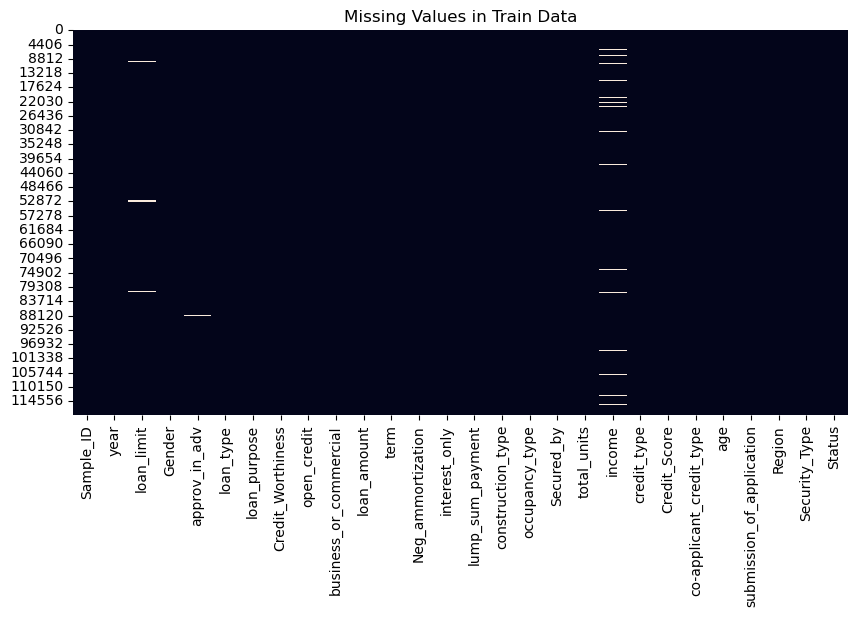

In [4]:
plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values in Train Data")
plt.show()

In [5]:
print(train['Status'].value_counts(),'\n')
print(train['Status'].value_counts(normalize=True))


Status
0    89625
1    29311
Name: count, dtype: int64 

Status
0    0.753557
1    0.246443
Name: proportion, dtype: float64


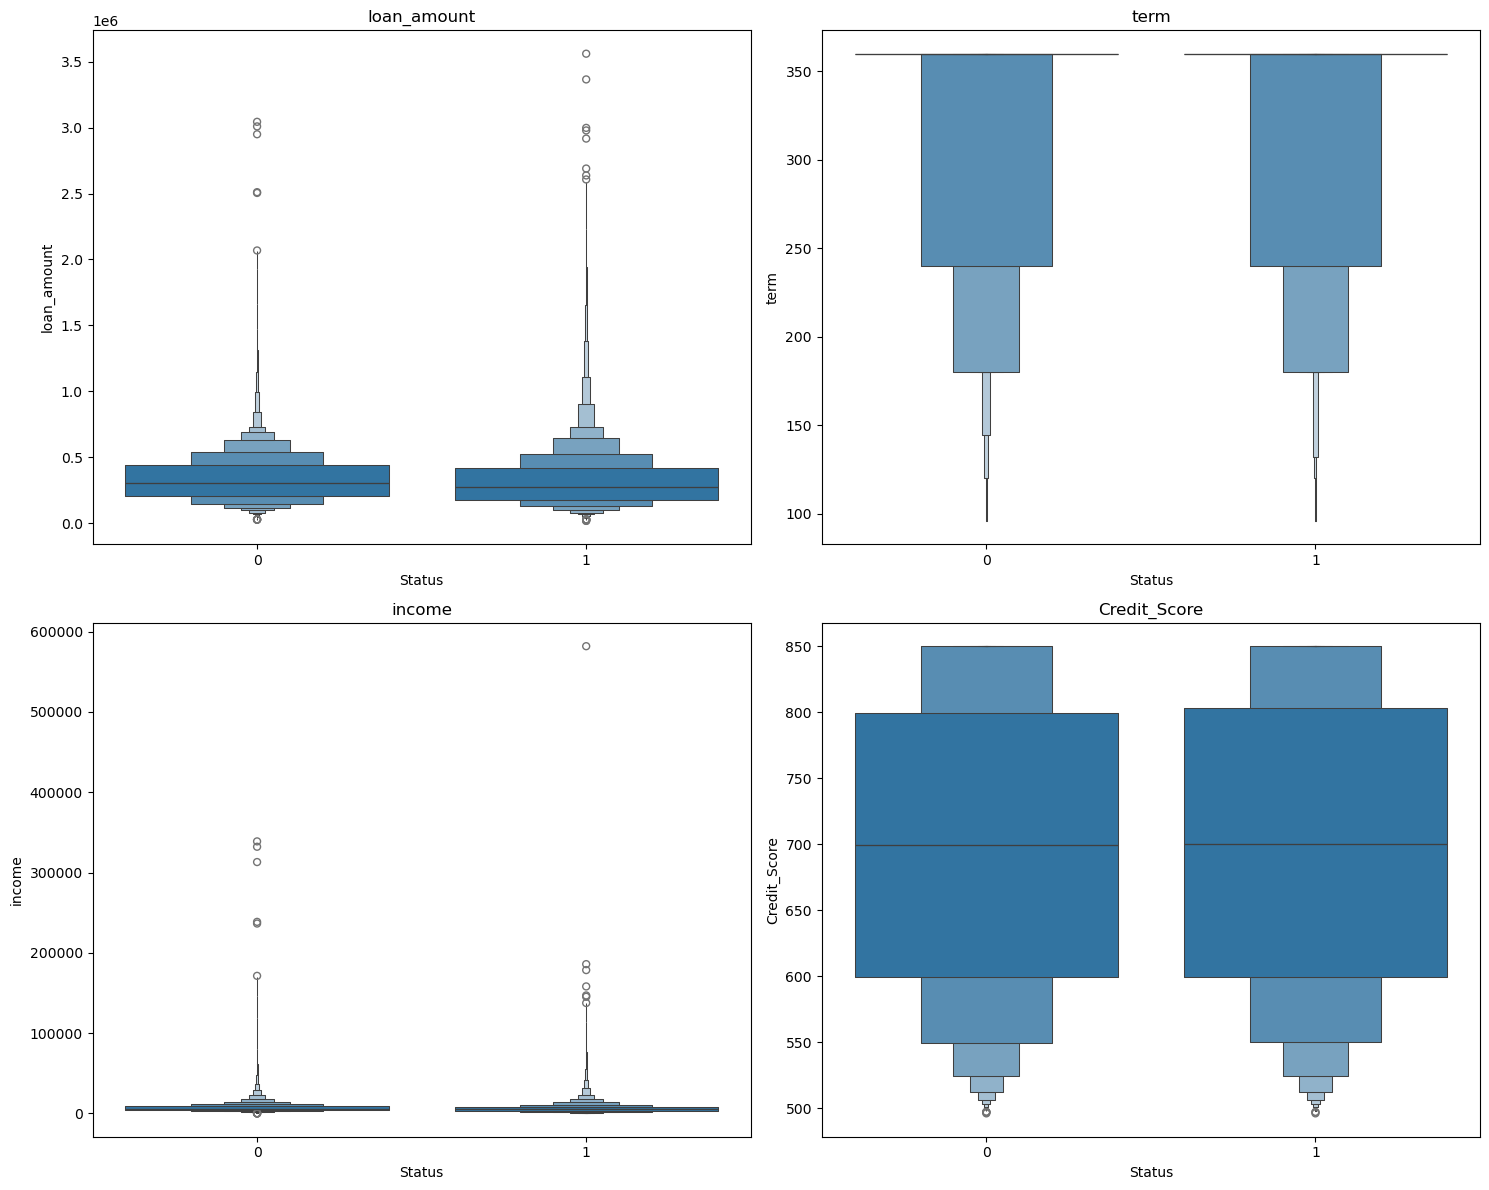

In [6]:

num_cols_eda = ['loan_amount', 'term', 'income', 'Credit_Score']

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(15, 12))

for i, col in enumerate(num_cols_eda):
    
    row = i // 2
    col_idx = i % 2
    
    sns.boxenplot(data=train, x='Status', y=col, ax=axs[row, col_idx])
    
    axs[row, col_idx].set_title(col)


plt.tight_layout()
plt.show()
    

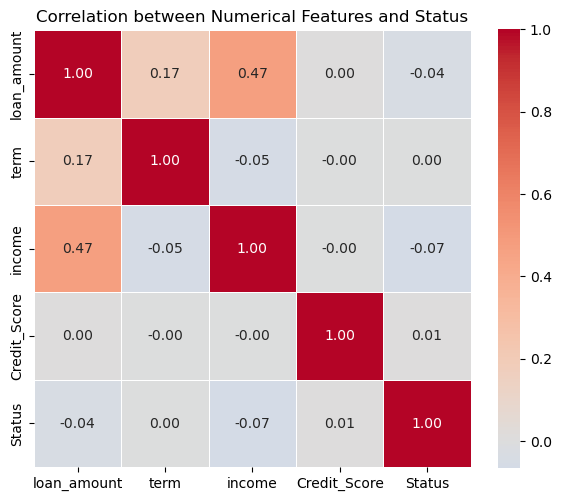

In [7]:
corr = train[num_cols_eda + ['Status']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation between Numerical Features and Status')
plt.tight_layout()
plt.show()

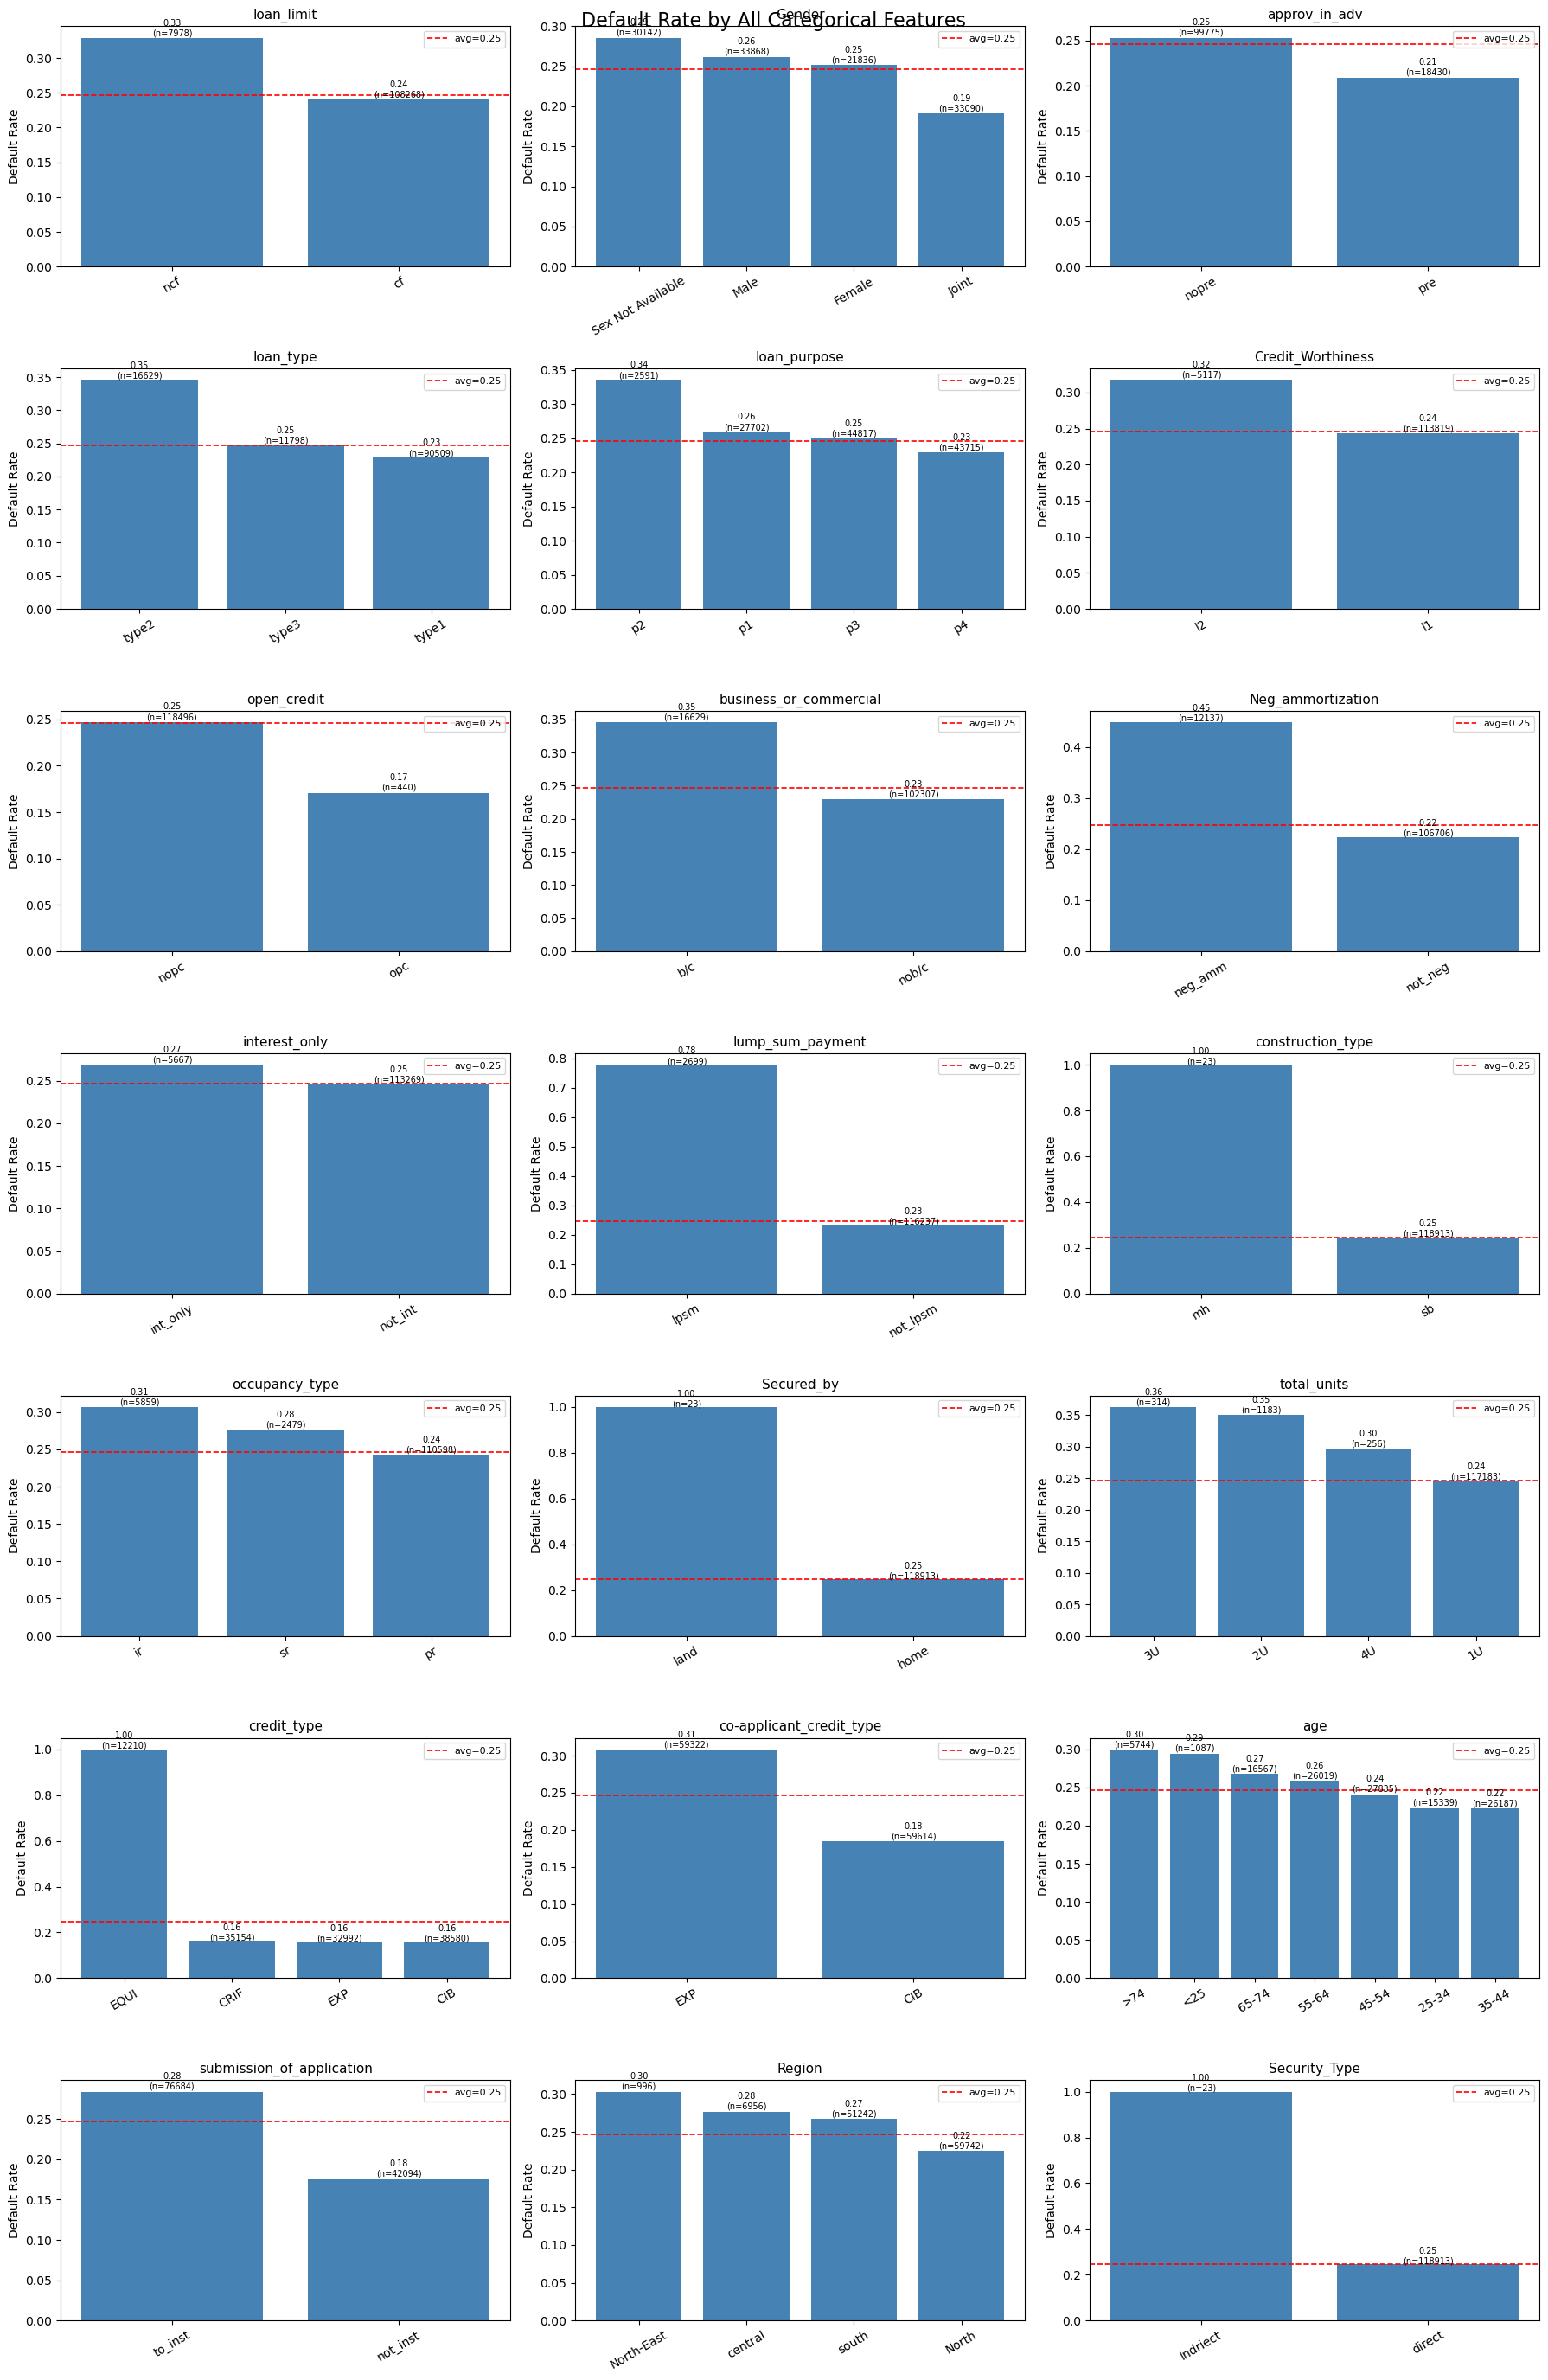

In [8]:
import math
import matplotlib.pyplot as plt

cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Sample_ID']
avg_default = train['Status'].mean()

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
fig.suptitle('Default Rate by All Categorical Features', fontsize=16)

axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    
    rate = train.groupby(col)['Status'].mean().sort_values(ascending=False)
    count = train.groupby(col)['Status'].count().loc[rate.index]

    x_labels = rate.index.astype(str)
    y_values = rate.values

    bars = ax.bar(x_labels, y_values, color='steelblue')

    ax.axhline(
        avg_default,
        color='red',
        linestyle='--',
        linewidth=1.2,
        label=f'avg={avg_default:.2f}'
    )

    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

    for bar, v, cnt in zip(bars, y_values, count.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{v:.2f}\n(n={cnt})',
            ha='center',
            fontsize=7
        )

for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 3. Feature / Target 분리


In [9]:
num_cols = [
    'loan_amount',
    'term',
    'income',
    'Credit_Score'
]
cat_cols = [
    'loan_limit', 
    'Gender', 
    'approv_in_adv', 
    'loan_type', 
    'loan_purpose',
    'Credit_Worthiness', 
    'open_credit', 
    'business_or_commercial',
    'Neg_ammortization', 
    'interest_only', 
    'lump_sum_payment',
    'construction_type', 
    'occupancy_type', 
    'Secured_by', 
    'total_units',
    'credit_type', 
    'co-applicant_credit_type', 
    'age',
    'submission_of_application', 
    'Region', 
    'Security_Type'
]

features = num_cols + cat_cols
X = train[features].copy()
y = train['Status']
X_test = test[features].copy()

## 4. Train / Validation 분리


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(f"X_train: {X_train.shape} / X_val: {X_val.shape}")

X_train: (95148, 25) / X_val: (23788, 25)


# 5. 전처리 Pipeline 정의


In [11]:
def build_preprocessor():
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', 
                                 handle_unknown='ignore',
                                 sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])

# 6. Model Selection - LR/DT/RF 기본 파라미터로 CV Screening


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', LogisticRegression(max_iter=1000,
                                 class_weight='balanced',
                                 random_state=42))
])
lr_scores = cross_val_score(lr_pipe, 
                            X_train, 
                            y_train, 
                            cv=cv, 
                            scoring="f1", 
                            n_jobs=-1) 
print(f'LR CV F1: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}')

dt_pipe = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', DecisionTreeClassifier(max_depth=10,
                                     class_weight='balanced',
                                     random_state=42))
])
dt_scores = cross_val_score(dt_pipe,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring='f1',
                            n_jobs=-1
)
print(f'DT CV F1: {dt_scores.mean():.4f} ± {dt_scores.std():.4f}')

rf_pipe =Pipeline([
    ('preprocessor', build_preprocessor()),
    ('model', RandomForestClassifier(n_estimators=100, 
                                     class_weight='balanced', 
                                     random_state=42, 
                                     n_jobs=-1))
])
rf_scores = cross_val_score(rf_pipe,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring='f1',
                            n_jobs=-1
                            )
print(f'RF CV F1: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}')

LR CV F1: 0.6364 ± 0.0059
DT CV F1: 0.6550 ± 0.0041
RF CV F1: 0.6541 ± 0.0085


# 7. Optuna 하이퍼파라미터 최적화 (DT, RF)


### DT Optuna


In [13]:
def objective_dt(trial):
    params = {
        'max_depth' : trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features' : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion' : trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }
    pipe = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('model', DecisionTreeClassifier(
            **params, class_weight='balanced', random_state=42
        ))
    ])
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1', n_jobs=-1)
    return scores.mean()

# study_dt.pkl 이 있으면 Optuna 를 다시 돌리지 않고 불러옴.
dt_study_path = 'study_dt.pkl'
# 저장된 파일이 있으면 로드, 없으면 Optuna 튜닝 실행 수 저장함.
if os.path.exists(dt_study_path):
    study_dt = joblib.load(dt_study_path)
    print('저장된 DT Optuna study를 불러왔습니다.')
else:
    study_dt = optuna.create_study(direction='maximize', study_name='DT_optimization')
    study_dt.optimize(objective_dt, n_trials=30, show_progress_bar=True)
    joblib.dump(study_dt, dt_study_path)
    print('DT Optuna study를 저장했습니다.')

print(f'DT  Best CV F1: {study_dt.best_value:.4f} | params: {study_dt.best_params}')

저장된 DT Optuna study를 불러왔습니다.
DT  Best CV F1: 0.6554 | params: {'max_depth': 11, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': None, 'criterion': 'gini'}


### RF Optuna


In [14]:
def objective_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth'        : trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
    }
    pipe = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('model', RandomForestClassifier(
            **params, class_weight='balanced', random_state=42, n_jobs=-1
        ))
    ])
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1', n_jobs=-1)
    return scores.mean()

# RF Optuna study 파일 경로 설정
rf_study_path = 'study_rf.pkl'
# 저장된 파일이 있으면 로드, 없으면 Optuna 튜닝 실행 후 저장
if os.path.exists(rf_study_path):
    study_rf = joblib.load(rf_study_path)
    print('저장된 RF Optuna study를 불러왔습니다.')
else:
    print('RF Optuna 최적화 시작 (n_trials=30)...')
    study_rf = optuna.create_study(direction='maximize', study_name='RF_optimization')
    study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)
    joblib.dump(study_rf, rf_study_path)
    print('RF Optuna study를 저장했습니다.')

print(f'RF  Best CV F1: {study_rf.best_value:.4f} | params: {study_rf.best_params}')

저장된 RF Optuna study를 불러왔습니다.
RF  Best CV F1: 0.6796 | params: {'n_estimators': 200, 'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': 0.5}


# 8. Validation 성능 평가


In [15]:
# [추가] validation 성능 확인용 모델 저장 파일 경로입니다.
# 이 파일이 있으면 RandomForest를 다시 학습하지 않고 바로 불러옵니다.
val_model_path = 'final_pipe_validation.pkl'

# [추가] 저장된 validation 모델이 있으면 로드, 없으면 학습 후 저장합니다.
if os.path.exists(val_model_path):
    final_pipe = joblib.load(val_model_path)
    print('저장된 validation 모델을 불러왔습니다.')
else:
    final_pipe = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('model', RandomForestClassifier(
            **study_rf.best_params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    final_pipe.fit(X_train, y_train)

    # [추가] 전처리 Pipeline + RandomForest 모델 전체를 저장합니다.
    joblib.dump(final_pipe, val_model_path)
    print('validation 모델을 학습하고 저장했습니다.')

y_val_pred = final_pipe.predict(X_val)

print(f'Validation F1: {f1_score(y_val, y_val_pred):.4f}')
print(classification_report(y_val, y_val_pred, target_names=['non-default(0)', 'default(1)']))

저장된 validation 모델을 불러왔습니다.
Validation F1: 0.6839
                precision    recall  f1-score   support

non-default(0)       0.88      0.95      0.91     17926
    default(1)       0.79      0.60      0.68      5862

      accuracy                           0.86     23788
     macro avg       0.83      0.78      0.80     23788
  weighted avg       0.86      0.86      0.86     23788



# 9. 전체 Train 으로 최종 모델 재학습

In [16]:
# [추가] 제출 파일 생성용 최종 모델 저장 파일 경로입니다.
# 전체 train 데이터(X, y)로 학습한 최종 Pipeline을 저장합니다.
final_model_path = 'final_pipe_full.pkl'

# [추가] 저장된 최종 모델이 있으면 로드, 없으면 전체 train 데이터로 학습 후 저장합니다.
if os.path.exists(final_model_path):
    final_pipe_full = joblib.load(final_model_path)
    print('저장된 전체 train 최종 모델을 불러왔습니다.')
else:
    final_pipe_full = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('model', RandomForestClassifier(
            **study_rf.best_params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    final_pipe_full.fit(X, y)

    # [추가] 전처리 Pipeline + 최종 RandomForest 모델 전체를 저장합니다.
    joblib.dump(final_pipe_full, final_model_path)
    print('전체 train 최종 모델을 학습하고 저장했습니다.')

저장된 전체 train 최종 모델을 불러왔습니다.


In [17]:
# [수정] test 예측에는 validation용 final_pipe가 아니라, 전체 train으로 학습한 final_pipe_full을 사용합니다.
test_pred = final_pipe_full.predict(X_test)

submission = pd.DataFrame({
    'Sample_ID': test['Sample_ID'],
    'Status'   : test_pred
})

output_filename = 'sample_id_status.csv'
submission.to_csv(output_filename, index=False)

display(submission.head(8))

,Sample_ID,Status
0,TE3963128,0
1,TE8623783,0
2,TE8266679,0
3,TE1992885,0
4,TE2674689,0
5,TE5677705,1
6,TE4980622,0
7,TE8898386,0
